This notebook aims to compare the pipelines obtained following the different imputation strategies on the MIMIC dataset. **This notebook requires `experiment.ipynb` to have been run**

In [1]:
import sys
sys.path.append('../')
from utils import *

In [2]:
# Reopen data
labs = pd.read_csv('data/labs_1_day.csv', index_col = [0, 1], header = [0, 1])
outcomes = pd.read_csv('data/outcomes_1_day.csv', index_col = 0)
outcomes['Death'] = outcomes.Death < 8 # Define binary outcome of interest

In [3]:
outcomes.ETHNICITY[outcomes.ETHNICITY.str.contains('BLACK')].value_counts() / outcomes.ETHNICITY.str.contains('BLACK').sum() * 100

ETHNICITY
BLACK/AFRICAN AMERICAN    91.801510
BLACK/CAPE VERDEAN         4.782452
BLACK/HAITIAN              2.445164
BLACK/AFRICAN              0.970874
Name: count, dtype: float64

In [4]:
# Define group of interest
ethnicity = outcomes.ETHNICITY.str.contains('BLACK').replace({True: 'Black', False: 'Non Black'}) 
ethnicity_unique = ['Black', 'Non Black']

gender = (outcomes.GENDER == 'M').replace({True: 'Male', False: 'Female'})
gender_unique = ['Female', 'Male']

insurance = (outcomes.INSURANCE == 'Private').replace({True: 'Private', False: 'Public'})
insurance_unique = ['Public', 'Private'] 

In [5]:
# To obtain the venn diagram
(ethnicity + ' + ' + gender + ' + ' + insurance).value_counts()

Non Black + Male + Public       12084
Non Black + Female + Public     10026
Non Black + Male + Private       7235
Non Black + Female + Private     4170
Black + Female + Public          1159
Black + Male + Public             890
Black + Male + Private            383
Black + Female + Private          349
Name: count, dtype: int64

In [6]:
results = 'results/'
threshold = 0.3

In [7]:
group_all = True # Is the group imputation taking all group or not into account

# Open results

In [8]:
import os

In [9]:
names = {
    file: file[file.rindex('classification')+14:file.rindex('.csv')]
    for file in os.listdir('results') if '.csv' in file
}

In [10]:
predictions = {}

for file in names:
    predictions[names[file]] = pd.read_csv(results + file, index_col=0)
    print(file, ' -> ', names[file])

names_reformat = ['Mean'] # Select methods to comapre
names_reformat += ['Group {} Mean'.format(g) for g in ['Ethnicity', 'Sex', 'Insurance', 'All']]
names_reformat += ['MICE']
names_reformat += ['Group {} MICE'.format(g) for g in ['Ethnicity', 'Sex', 'Insurance', 'All']]
names_reformat += ['Group {} MICE Missing'.format(g) for g in ['Ethnicity', 'Sex', 'Insurance', 'All']]
predictions = {name: predictions[name] for name in names_reformat[::-1]}

classificationMean.csv  ->  Mean
classificationGroup All Mean.csv  ->  Group All Mean
classificationGroup All MICE Missing.csv  ->  Group All MICE Missing
classificationGroup Ethnicity MICE Missing.csv  ->  Group Ethnicity MICE Missing
classificationGroup All MICE.csv  ->  Group All MICE
classificationMICE.csv  ->  MICE
classificationGroup Sex MICE Missing.csv  ->  Group Sex MICE Missing
classificationGroup Insurance MICE Missing.csv  ->  Group Insurance MICE Missing
classificationGroup All Mean Missing.csv  ->  Group All Mean Missing
classificationGroup Insurance Mean Missing.csv  ->  Group Insurance Mean Missing
classificationGroup Sex Mean.csv  ->  Group Sex Mean
classificationMICE Missing.csv  ->  MICE Missing
classificationGroup Ethnicity Mean.csv  ->  Group Ethnicity Mean
classificationGroup Sex MICE.csv  ->  Group Sex MICE
classificationGroup Sex Mean Missing.csv  ->  Group Sex Mean Missing
classificationGroup Ethnicity Mean Missing.csv  ->  Group Ethnicity Mean Missing
classifi

# Performances

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss

Differencesin observed labels between training and testing 

### All metrics

Evaluate all metrics on datasets

In [12]:
def evaluate(y_true, groups, groups_unique, y_pred, iterations = 100, p = threshold):
    """
        Compute boostrapped performances
    """
    fprs, tprs, rocs, brs, screened, screened_fpr, screened_fnr = {b: [] for b in groups_unique}, {b: [] for b in groups_unique}, \
        {b: [] for b in groups_unique}, {b: [] for b in groups_unique}, {b: [] for b in groups_unique}, {b: [] for b in groups_unique}, {b: [] for b in groups_unique}

    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    fpr_sort = np.argsort(fpr)
    tpr_sort = np.argsort(tpr)
    threshold_fpr = np.interp(0.9, tpr[tpr_sort], thresholds[tpr_sort])
    threshold_tpr = np.interp(0.1, fpr[fpr_sort], thresholds[fpr_sort])

    # Threshold screening
    threshold_top = pd.Series(y_pred).nlargest(int(len(y_pred) * p), keep = 'all').min()

    for group in groups_unique:
        if group == 'Overall':
            y_pred_group = y_pred
            y_true_group = y_true
        else:
            y_pred_group = y_pred[groups == group]
            y_true_group = y_true[groups == group]

        for i in range(iterations):
            bootstrap = np.random.choice(np.arange(len(y_pred_group)), size = len(y_pred_group), replace = True) 
            y_pred_iteration = y_pred_group[bootstrap]
            y_true_iteration = y_true_group[bootstrap]

            # Standard metrics on the boostrapped sample
            brs[group].append(brier_score_loss(y_true_iteration, y_pred_iteration))
            fpr, tpr, thresholds = roc_curve(y_true_iteration, y_pred_iteration)
            thres_order = np.argsort(thresholds)
            fprs[group].append(np.interp(threshold_fpr, thresholds[thres_order], fpr[thres_order]))
            tprs[group].append(np.interp(threshold_tpr, thresholds[thres_order], tpr[thres_order]))
            rocs[group].append(roc_auc_score(y_true_iteration, y_pred_iteration))

            # Percentage screened-out in bottom 30 %
            selected = y_pred_iteration >= threshold_top
            screened[group].append(np.mean(selected)) # Percentage of patients in this group that are prioritized
            screened_fnr[group].append((y_true_iteration[~selected]).sum() / y_true_iteration.sum()) # Wrongly not prioritized
            screened_fpr[group].append((1 - y_true_iteration[selected]).sum() / (1 - y_true_iteration).sum()) # Wrongly prioritized

    result = {}
    if len(groups_unique) == 2:
        difference = 'Difference {} - {}'.format(groups_unique[0], groups_unique[1])
        result.update({
            (difference, "Brier Score", 'Mean'): np.mean(np.array(brs[groups_unique[0]]) - np.array(brs[groups_unique[1]])),
            (difference, "Brier Score", 'Std'): np.std(np.array(brs[groups_unique[0]]) - np.array(brs[groups_unique[1]])),
            (difference, "AUC ROC", 'Mean'): np.mean(np.array(rocs[groups_unique[0]]) - np.array(rocs[groups_unique[1]])),
            (difference, "AUC ROC", 'Std'): np.std(np.array(rocs[groups_unique[0]]) - np.array(rocs[groups_unique[1]])),

            (difference, "FPR @ 90% TPR", 'Mean'): np.mean(np.array(fprs[groups_unique[0]]) - np.array(fprs[groups_unique[1]])),
            (difference, "FPR @ 90% TPR", 'Std'): np.std(np.array(fprs[groups_unique[0]]) - np.array(fprs[groups_unique[1]])),
            (difference, "TPR @ 10% FPR", 'Mean'): np.mean(np.array(tprs[groups_unique[0]]) - np.array(tprs[groups_unique[1]])),
            (difference, "TPR @ 10% FPR", 'Std'): np.std(np.array(tprs[groups_unique[0]]) - np.array(tprs[groups_unique[1]])),

            (difference, "Prioritized", 'Mean'): np.mean(np.array(screened[groups_unique[0]]) - np.array(screened[groups_unique[1]])),
            (difference, "Prioritized", 'Std'): np.std(np.array(screened[groups_unique[0]]) - np.array(screened[groups_unique[1]])),
            (difference, "Wrongly prioritized (FPR)", 'Mean'): np.mean(np.array(screened_fpr[groups_unique[0]]) - np.array(screened_fpr[groups_unique[1]])),
            (difference, "Wrongly prioritized (FPR)", 'Std'): np.std(np.array(screened_fpr[groups_unique[0]]) - np.array(screened_fpr[groups_unique[1]])),
            (difference, "Wrongly not prioritized (FNR)", 'Mean'): np.mean(np.array(screened_fnr[groups_unique[0]]) - np.array(screened_fnr[groups_unique[1]])),
            (difference, "Wrongly not prioritized (FNR)", 'Std'): np.std(np.array(screened_fnr[groups_unique[0]]) - np.array(screened_fnr[groups_unique[1]])),
        })
    for group in groups_unique:
        result.update({
            (group, "Brier Score", 'Mean'): np.mean(brs[group]),
            (group, "Brier Score", 'Std'): np.std(brs[group]),
            (group, "AUC ROC", 'Mean'): np.mean(rocs[group]),
            (group, "AUC ROC", 'Std'): np.std(rocs[group]),

            (group, "FPR @ 90% TPR", 'Mean'): np.mean(fprs[group]),
            (group, "FPR @ 90% TPR", 'Std'): np.std(fprs[group]),
            (group, "TPR @ 10% FPR", 'Mean'): np.mean(tprs[group]),
            (group, "TPR @ 10% FPR", 'Std'): np.std(tprs[group]),

            (group, "Prioritized", 'Mean'): np.mean(screened[group]),
            (group, "Prioritized", 'Std'): np.std(screened[group]),
            (group, "Wrongly prioritized (FPR)", 'Mean'): np.mean(screened_fpr[group]),
            (group, "Wrongly prioritized (FPR)", 'Std'): np.std(screened_fpr[group]),
            (group, "Wrongly not prioritized (FNR)", 'Mean'): np.mean(screened_fnr[group]),
            (group, "Wrongly not prioritized (FNR)", 'Std'): np.std(screened_fnr[group]),
        })
    return pd.Series(result)

In [13]:
# Compute and display performances per group of model
performances = {}
for groups, groups_unique, group_name in [(gender, gender_unique, 'Sex'), (ethnicity, ethnicity_unique, 'Ethnicity'), (insurance, insurance_unique, 'Insurance'), (outcomes, ['Overall'], 'Overall')]:
    print('-' * 42)
    print('Computing for group: ', group_name)
    perf_group = {}
    for m in predictions:

        if (group_name != 'Overall'):
            if group_all and (('Group' in m) and not('All' in m)): 
                continue
            elif not(group_all) and (('Group' in m) and not(group_name in m)):
                continue

        print('\t- ', m)

        np.random.seed(42)
        preds = predictions[m]

        test = preds.Use != 'Train' # Use the data that will be used for both   
        test = test[test].index

        if (group_name != 'Overall') and ('Group' in m):
            # Rename method to explore group specific mean
            m = 'Group Mean{}'.format(' Missing' if 'Miss' in m else '') if 'Mean' in m else 'Group MICE{}'.format(' Missing' if 'Miss' in m else '')

        if m == 'Mean':
            m = 'Population Mean'
        
        perf_group[m] = evaluate(outcomes.Death.loc[test].values, groups.loc[test].values, groups_unique, preds.loc[test]['Mean'].values)
    performances[group_name] = pd.concat(perf_group, axis = 1).T

------------------------------------------
Computing for group:  Sex
	-  Group All MICE Missing
	-  Group All MICE
	-  MICE
	-  Group All Mean
	-  Mean
------------------------------------------
Computing for group:  Ethnicity
	-  Group All MICE Missing
	-  Group All MICE
	-  MICE
	-  Group All Mean
	-  Mean
------------------------------------------
Computing for group:  Insurance
	-  Group All MICE Missing
	-  Group All MICE
	-  MICE
	-  Group All Mean
	-  Mean
------------------------------------------
Computing for group:  Overall
	-  Group All MICE Missing
	-  Group Insurance MICE Missing
	-  Group Sex MICE Missing
	-  Group Ethnicity MICE Missing
	-  Group All MICE
	-  Group Insurance MICE
	-  Group Sex MICE
	-  Group Ethnicity MICE
	-  MICE
	-  Group All Mean
	-  Group Insurance Mean
	-  Group Sex Mean
	-  Group Ethnicity Mean
	-  Mean


### Display performance

In [14]:
metric = "Wrongly not prioritized (FNR)" #'Prioritized', 'AUC ROC', 'Wrongly not prioritized (FNR)'

In [15]:
for groups, groups_unique, group_name in [(gender, gender_unique, 'Sex'), (ethnicity, ethnicity_unique, 'Ethnicity'), (insurance, insurance_unique, 'Insurance'), (outcomes, ['Overall'], 'Overall')]:
    perf_group = performances[group_name][groups_unique]
    perf_group = perf_group.loc[:, perf_group.columns.get_level_values(1) == metric].droplevel(1, 1)
    perf_group = pd.DataFrame.from_dict({model: ["{:.3f} ({:.3f})".format(perf_group.loc[model].loc[i].Mean, perf_group.loc[model].loc[i].Std) for i in perf_group.loc[model].index.get_level_values(0).unique()] for model in perf_group.index}, columns = perf_group.columns.get_level_values(0).unique(), orient = 'index')
    print(perf_group.T.to_latex())
perf_group.T

\begin{tabular}{llllll}
\toprule
 & Group MICE Missing & Group MICE & MICE & Group Mean & Population Mean \\
\midrule
Female & 0.305 (0.025) & 0.346 (0.030) & 0.381 (0.030) & 0.327 (0.026) & 0.348 (0.030) \\
Male & 0.298 (0.024) & 0.386 (0.027) & 0.358 (0.026) & 0.401 (0.026) & 0.367 (0.027) \\
\bottomrule
\end{tabular}

\begin{tabular}{llllll}
\toprule
 & Group MICE Missing & Group MICE & MICE & Group Mean & Population Mean \\
\midrule
Black & 0.337 (0.068) & 0.379 (0.073) & 0.314 (0.078) & 0.441 (0.082) & 0.271 (0.074) \\
Non Black & 0.299 (0.017) & 0.365 (0.017) & 0.372 (0.018) & 0.361 (0.018) & 0.366 (0.017) \\
\bottomrule
\end{tabular}

\begin{tabular}{llllll}
\toprule
 & Group MICE Missing & Group MICE & MICE & Group Mean & Population Mean \\
\midrule
Public & 0.279 (0.019) & 0.326 (0.020) & 0.351 (0.019) & 0.308 (0.018) & 0.336 (0.019) \\
Private & 0.382 (0.039) & 0.497 (0.037) & 0.418 (0.037) & 0.565 (0.040) & 0.437 (0.041) \\
\bottomrule
\end{tabular}

\begin{tabular}{llllllll

,Group All MICE Missing,Group Insurance MICE Missing,Group Sex MICE Missing,Group Ethnicity MICE Missing,Group All MICE,Group Insurance MICE,Group Sex MICE,Group Ethnicity MICE,MICE,Group All Mean,Group Insurance Mean,Group Sex Mean,Group Ethnicity Mean,Population Mean
Overall,0.302 (0.018),0.297 (0.018),0.289 (0.019),0.292 (0.018),0.367 (0.021),0.377 (0.019),0.384 (0.019),0.368 (0.019),0.368 (0.018),0.369 (0.020),0.379 (0.020),0.367 (0.020),0.359 (0.020),0.361 (0.020)


Text(0.5, -0.05, 'Wrongly not prioritized (FNR)')



In [16]:
fig, ax = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (15, 5))
for i, (groups_unique, group_name) in enumerate([(gender_unique, 'Sex'), (ethnicity_unique, 'Ethnicity'), (insurance_unique, 'Insurance')]):
    perf_group = performances[group_name][groups_unique]
    perf_group = perf_group.loc[:, perf_group.columns.get_level_values(1) == metric].droplevel(1, 1)[::-1]

    ax[i].set_title(group_name)
    last, patches = 0, []
    for group, color in zip(groups_unique, ['tab:blue', 'tab:orange']): # Order matters (marginalised first)
        perf_group[(group, 'Mean')].plot.barh(ax = ax[i], xerr = 1.96 * perf_group[(group, 'Std')] / np.sqrt(100), label = group)

        # Remove bar and replace with scatter 
        for j, thisbar in enumerate(ax[i].patches):
            if j >= last:
                thisbar.set(alpha = 0)
                dot = ax[i].scatter(thisbar.get_width(), thisbar.get_y() + thisbar.get_height() / 2, alpha = 0.7,
                            marker = 'o', s = 125, color = color, linewidths=3)
                last += 1

                # Link groups
                if j - len(perf_group) >= 0:
                    other_bar = ax[i].patches[j - len(perf_group)]
                    ax[i].plot([thisbar.get_width(), other_bar.get_width()], [thisbar.get_y() + thisbar.get_height() / 2, other_bar.get_y() + other_bar.get_height() / 2], color = 'black', linestyle = '--', alpha = 0.5)

        patches += [dot]

plt.legend(patches, ['Marginalised', 'Majority'], loc='upper left', bbox_to_anchor=(1., 1.04), frameon=False,
        handletextpad = 0.5, handlelength = 1.0, columnspacing = -0.5,)
plt.xlim(0.2, 0.6)
fig.supxlabel(metric, y = -0.05)

#### Difference in FNR

In [17]:
comparison = {}
for model in performances['Sex'].index[::-1]:
    comparison[model] = pd.concat({
        'Insurance': performances['Insurance'].loc[model]['Difference Public - Private'][metric],
        'Sex': performances['Sex'].loc[model]['Difference Female - Male'][metric],
        'Ethnicity': performances['Ethnicity'].loc[model]['Difference Black - Non Black'][metric],
    }, axis = 1).T

In [18]:
metrics_short = {
    "Brier Score": "Brier",
    "AUC ROC": "AUC",
    "FPR @ 90% TPR": "False Positive Rate",
    "TPR @ 10% FPR": "True Positive Rate",
    "Prioritized": "Prioritisation",
    "Wrongly prioritized (FPR)": "False Positive Rate",
    "Wrongly not prioritized (FNR)": "False Negative Rate"
}

In [19]:
comparison = pd.concat(comparison, axis = 1).swaplevel(0, axis = 1)
comparison

,Mean,Std,Mean,Std,Mean,Std,Mean,Std,Mean,Std
,Population Mean,Population Mean,Group Mean,Group Mean,MICE,MICE,Group MICE,Group MICE,Group MICE Missing,Group MICE Missing
Insurance,-0.100509,0.045080,-0.257351,0.043143,-0.067063,0.040180,-0.171196,0.040928,-0.102623,0.044285
Sex,-0.019495,0.040087,-0.074092,0.034862,0.022805,0.040922,-0.040683,0.041186,0.007210,0.034231
Ethnicity,-0.095198,0.075311,0.079708,0.084984,-0.057697,0.080452,0.014419,0.075693,0.037622,0.071692


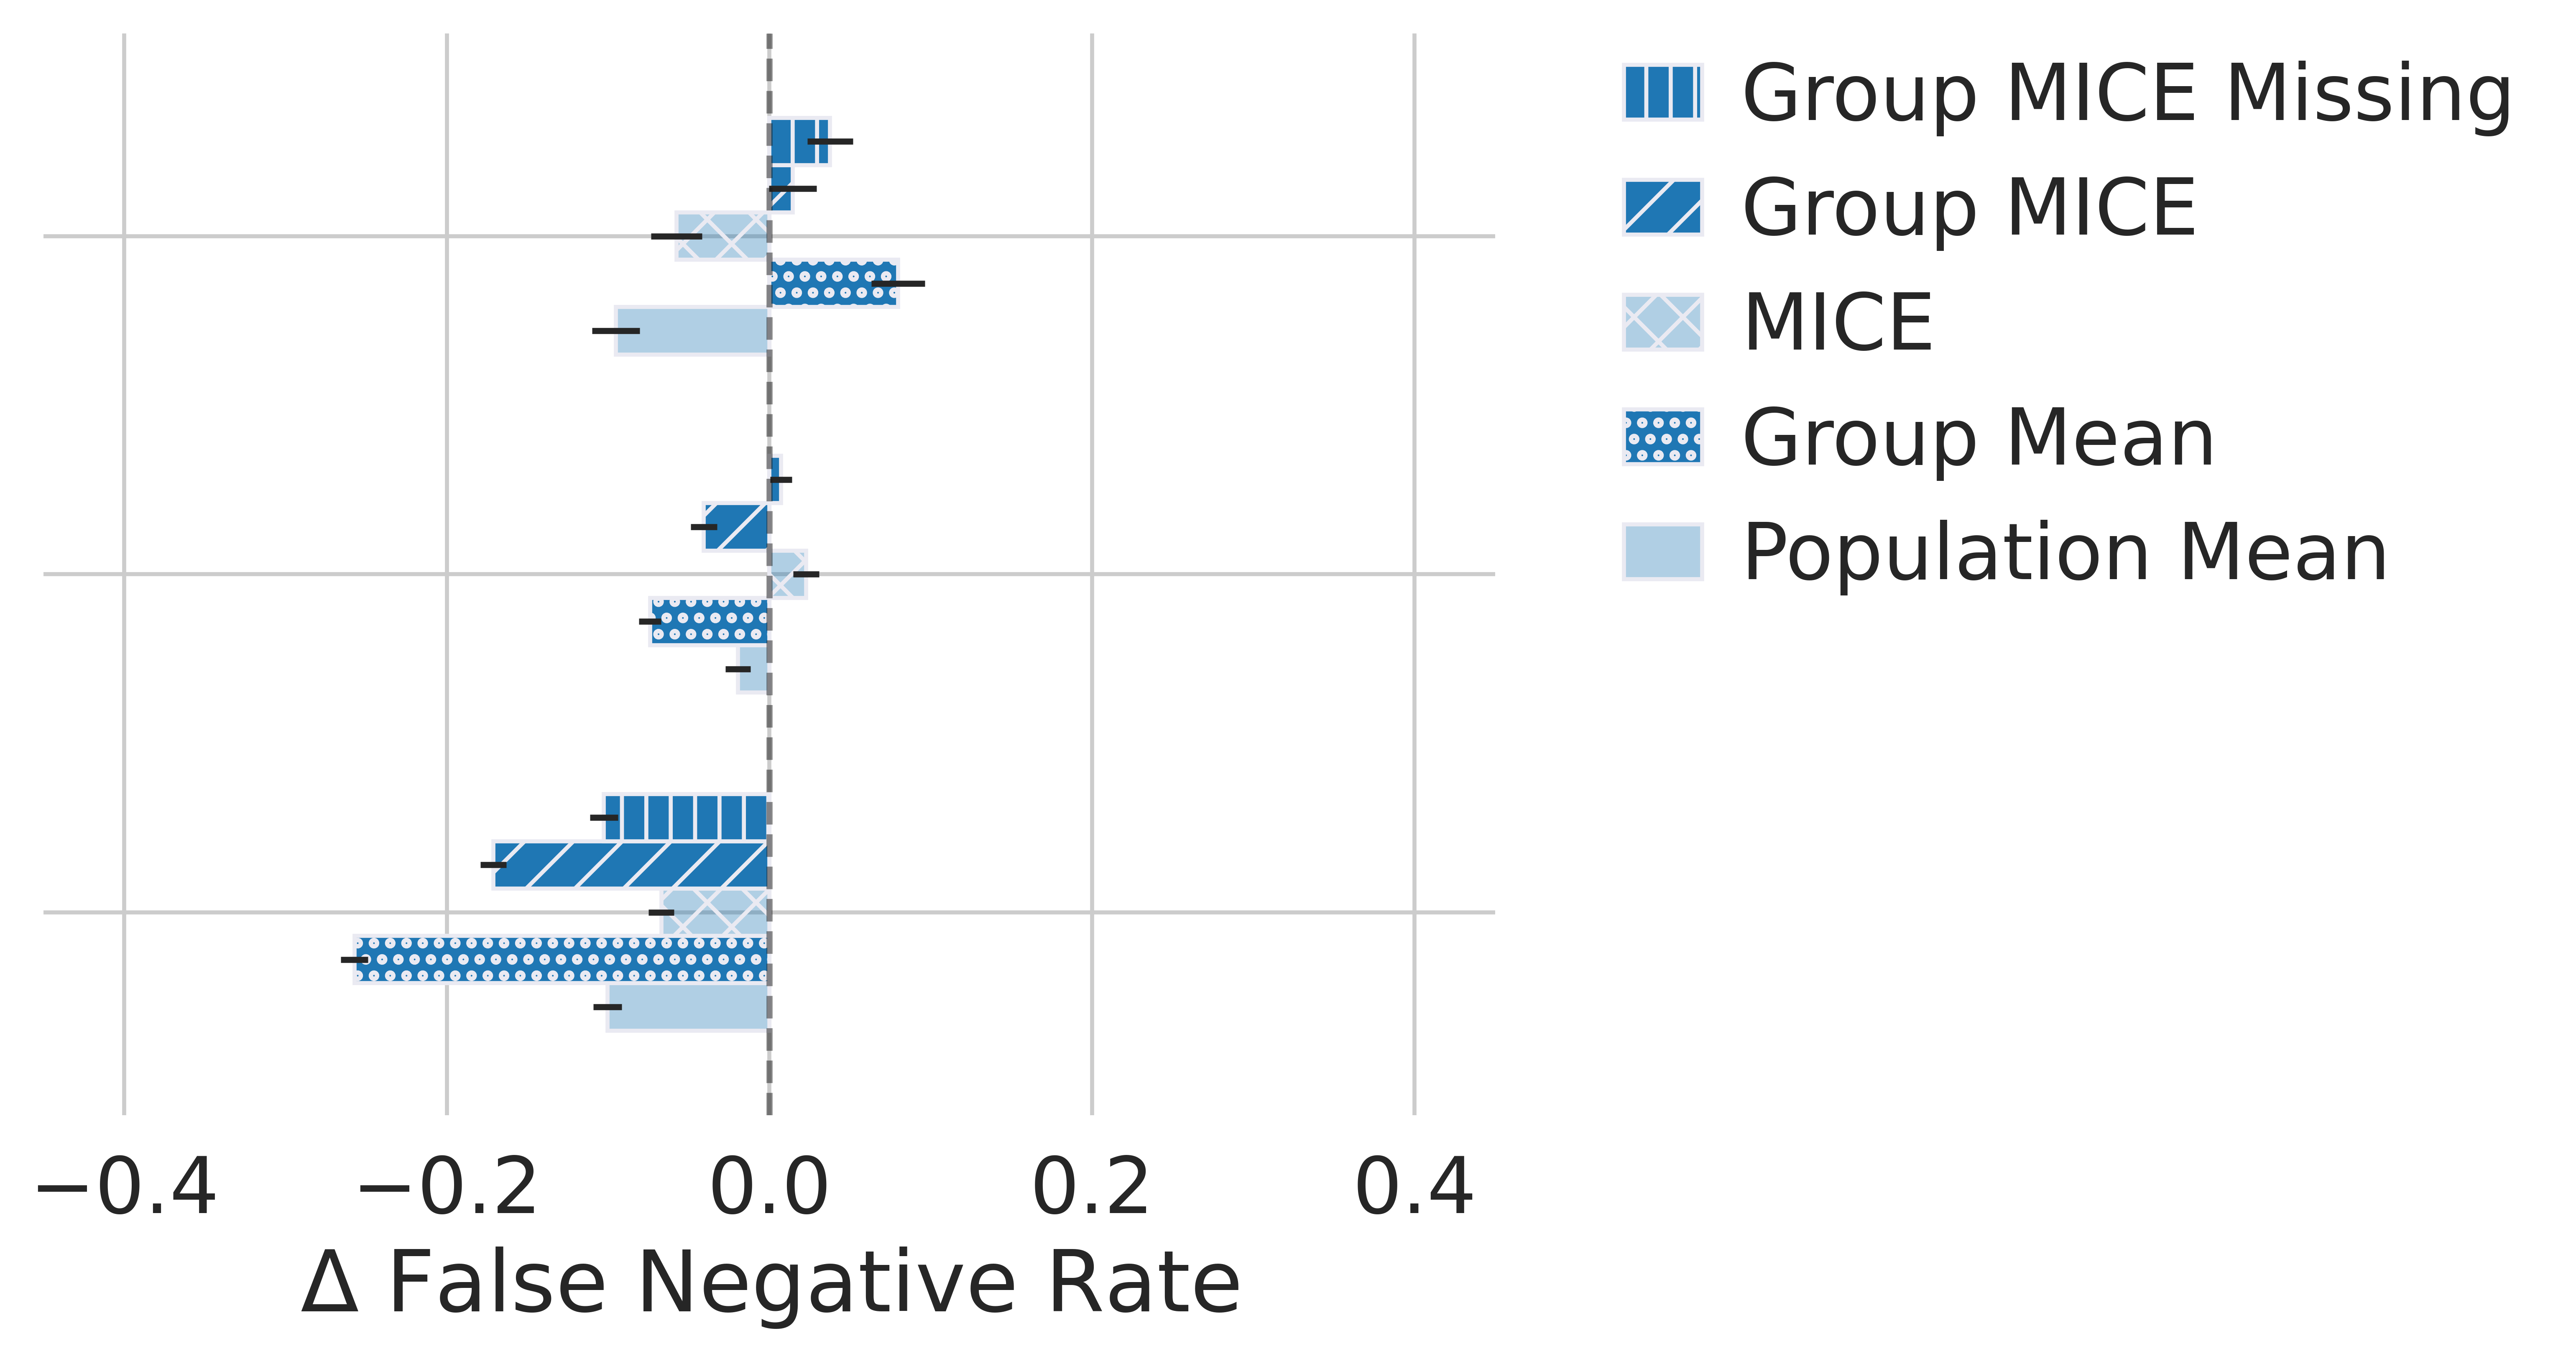

In [20]:
ax = comparison.Mean.plot.barh(xerr = 1.96 * comparison.Std / np.sqrt(100), width = 0.7, legend = 'FNR' in metric, figsize = (6.4, 4.8))
hatches = ['', 'ooo', 'xx', '//', '||', '***', '++']
for i, thisbar in enumerate(ax.patches):
    c = list(plt_colors.to_rgba('tab:blue'))
    c[3] = 0.35 if i // len(comparison) in [0,2] else 1
    thisbar.set(edgecolor = '#eaeaf2', facecolor = c, linewidth = 1, hatch = hatches[i // len(comparison)])

if 'FNR' in metric:
    patches = [ax.patches[i * len(comparison)] for i in range(len(comparison.Mean.columns))][::-1]
    labels = comparison.Mean.columns.tolist()[::-1]

    ax.legend(patches, labels, loc='upper left', bbox_to_anchor=(1.04, 1.04), frameon=False,
        handletextpad = 0.5, handlelength = 1.0, columnspacing = -0.5,)
    ax.set_yticklabels([])

if 'AUC' in metric:
    plt.xlim(-0.11, 0.12)
else:
    plt.xlim(-0.45, 0.45)
plt.axvline(0, ls = '--', alpha = 0.5, c = 'k')
plt.xlabel('$\Delta$ {}'.format(metrics_short[metric]))
plt.show()

In [21]:
comparison

,Mean,Std,Mean,Std,Mean,Std,Mean,Std,Mean,Std
,Population Mean,Population Mean,Group Mean,Group Mean,MICE,MICE,Group MICE,Group MICE,Group MICE Missing,Group MICE Missing
Insurance,-0.100509,0.045080,-0.257351,0.043143,-0.067063,0.040180,-0.171196,0.040928,-0.102623,0.044285
Sex,-0.019495,0.040087,-0.074092,0.034862,0.022805,0.040922,-0.040683,0.041186,0.007210,0.034231
Ethnicity,-0.095198,0.075311,0.079708,0.084984,-0.057697,0.080452,0.014419,0.075693,0.037622,0.071692


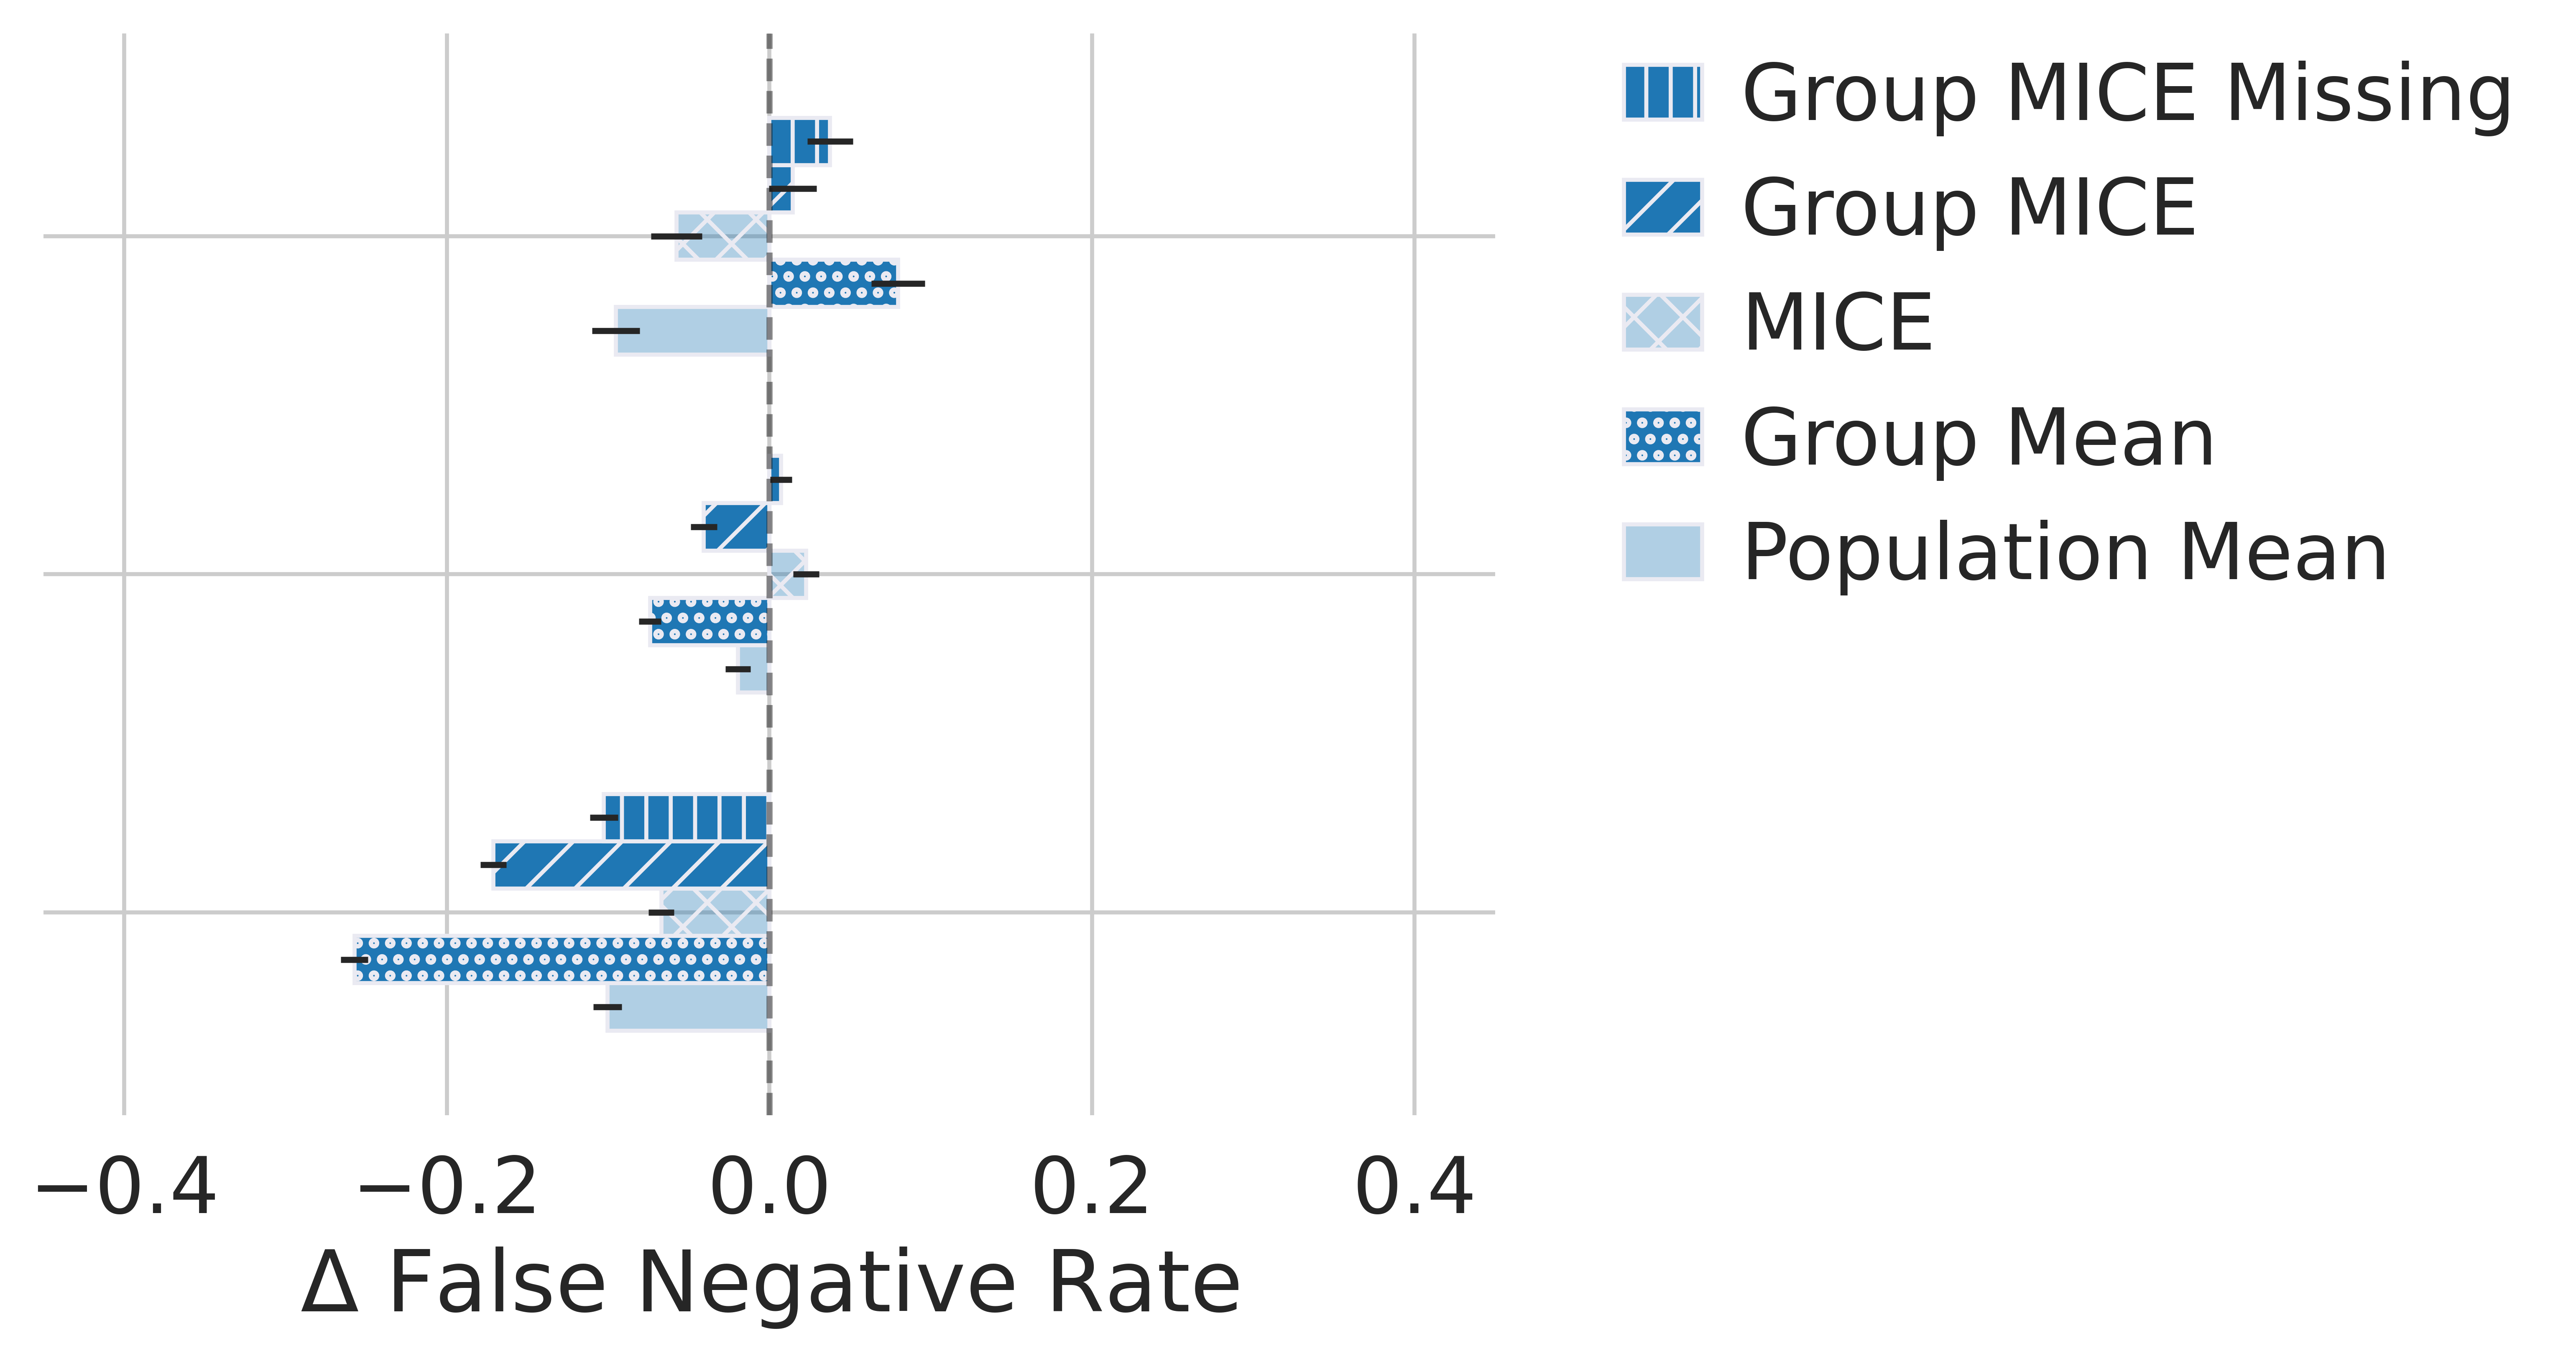

In [22]:
ax = comparison.Mean.plot.barh(xerr = 1.96 * comparison.Std / np.sqrt(100), width = 0.7, legend = 'FNR' in metric, figsize = (6.4, 4.8))
hatches = ['', 'ooo', 'xx', '//', '||', '***', '++']
for i, thisbar in enumerate(ax.patches):
    c = list(plt_colors.to_rgba('tab:blue'))
    c[3] = 0.35 if i // len(comparison) in [0,2] else 1
    thisbar.set(edgecolor = '#eaeaf2', facecolor = c, linewidth = 1, hatch = hatches[i // len(comparison)])

if 'FNR' in metric:
    patches = [ax.patches[i * len(comparison)] for i in range(len(comparison.Mean.columns))][::-1]
    labels = comparison.Mean.columns.tolist()[::-1]

    ax.legend(patches, labels, loc='upper left', bbox_to_anchor=(1.04, 1.04), frameon=False,
        handletextpad = 0.5, handlelength = 1.0, columnspacing = -0.5,)
    ax.set_yticklabels([])

if 'AUC' in metric:
    plt.xlim(-0.11, 0.12)
else:
    plt.xlim(-0.45, 0.45)
plt.axvline(0, ls = '--', alpha = 0.5, c = 'k')
plt.xlabel('$\Delta$ {}'.format(metrics_short[metric]))
plt.show()

In [23]:
print(pd.DataFrame.from_dict({group: ["{:.3f} ({:.3f})".format(comparison.loc[group].loc[('Mean', i)], comparison.loc[group].loc[('Std', i)]) for i in comparison.loc[group].index.get_level_values(1).unique()] for group in comparison.index}, columns = comparison.columns.get_level_values(1).unique(), orient = 'index').to_latex())

\begin{tabular}{llllll}
\toprule
 & Population Mean & Group Mean & MICE & Group MICE & Group MICE Missing \\
\midrule
Insurance & -0.101 (0.045) & -0.257 (0.043) & -0.067 (0.040) & -0.171 (0.041) & -0.103 (0.044) \\
Sex & -0.019 (0.040) & -0.074 (0.035) & 0.023 (0.041) & -0.041 (0.041) & 0.007 (0.034) \\
Ethnicity & -0.095 (0.075) & 0.080 (0.085) & -0.058 (0.080) & 0.014 (0.076) & 0.038 (0.072) \\
\bottomrule
\end{tabular}

